 # Multi-City Weather Data Validation & Unsupervised ML Clustering

 Compares **AidWeather**, **Meteostat**, and **Open-Meteo ERA5** against
 local official **INMET BDMEP** station observations across 10 geographically
 scattered Brazilian cities.

 **Approach:**
 - 5 state capitals + 5 nearby agricultural hubs (one per region)
 - Statistical error metrics (MAE, RMSE, Pearson r) vs. INMET ground truth
 - Unsupervised ML: combined climate-profile features → StandardScaler →
   PCA + t-SNE dimensionality reduction + K-Means clustering (K=5)
 - Three combinatory scatter p lot variants per projection for visual clarity

In [ ]:
import pathlib
import sys
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import meteostat as ms
import numpy as np
import openmeteo_requests
import pandas as pd
import requests_cache
import seaborn as sns
from retry_requests import retry
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Add the src/ directory to path so aidweather is importable from the scratchpad
_WORKSPACE_DIR = pathlib.Path(__file__).resolve().parents[1]
sys.path.insert(0, str(_WORKSPACE_DIR / "src"))

try:
    import sys
except ImportError:
    from src.aidweather import PowerClient  # type: ignore[no-redef]

# Avoid noisy third-party warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Execution-context detection
# ---------------------------------------------------------------------------
try:
    _ipy = get_ipython()  # type: ignore[name-defined]
    IS_NOTEBOOK = _ipy is not None
except NameError:
    IS_NOTEBOOK = False

_SCRIPT_DIR = pathlib.Path(__file__).resolve().parent if not IS_NOTEBOOK else pathlib.Path(".").resolve()
if _SCRIPT_DIR.name in ("scripts", "notebooks"):
    _VALIDATION_DIR = _SCRIPT_DIR.parent
else:
    _VALIDATION_DIR = _SCRIPT_DIR

_WORKSPACE_DIR = _VALIDATION_DIR.parent.parent
sys.path.insert(0, str(_WORKSPACE_DIR / "src"))

try:
    from aidweather import PowerClient
except ImportError:
    from src.aidweather import PowerClient  # type: ignore[no-redef]

PLOT_DIR = _VALIDATION_DIR / "plots"
if not IS_NOTEBOOK:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Plots will be saved to: {PLOT_DIR.resolve()}")


def save_or_show(filename: str) -> None:
    """Save figure to PLOT_DIR when running as a script, show inline otherwise."""
    if IS_NOTEBOOK:
        plt.show()
    else:
        out_path = PLOT_DIR / filename
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"Saved: {out_path}")

 ## 1. Configuration — Cities, Year, and Data Directory

In [ ]:
# ---------------------------------------------------------------------------
# Target Cities and INMET filename patterns
# ---------------------------------------------------------------------------
# Five capitals paired with a nearby agricultural hub, one pair per region.
TARGET_CITIES = {
    # North
    "MANAUS_CAPITAL": ("*MANAUS*.CSV", "A101"),
    "ITACOATIARA_AGRI": ("*ITACOATIARA*.CSV", "A121"),
    # Northeast
    "SALVADOR_CAPITAL": ("*SALVADOR*.CSV", "A401"),
    "CRUZ_DAS_ALMAS_AGRI": ("*CRUZ*ALMAS*.CSV", "A406"),
    # Central-West
    "BRASILIA_CAPITAL": ("*BRASILIA*.CSV", "A001"),
    "PARANOA_AGRI": ("*PARANOA*.CSV", "A047"),
    # Southeast
    "SAO_PAULO_CAPITAL": ("*SAO*PAULO*.CSV", "A701"),
    "PIRACICABA_AGRI": ("*PIRACICABA*.CSV", "A726"),
    # South
    "PORTO_ALEGRE_CAPITAL": ("*PORTO*ALEGRE*.CSV", "A801"),
    "BENTO_GONCALVES_AGRI": ("*BENTO*GONCALVES*.CSV", "A840"),
}

TEST_MODE = False

if TEST_MODE:
    start = datetime(2024, 1, 1)
    end = datetime(2024, 3, 31)
else:
    start = datetime(2021, 1, 1)
    end = datetime(2026, 6, 30)

INMET_DATA_DIR = _VALIDATION_DIR / "data"

print(
    f"TEST_MODE: {TEST_MODE} | Period: {start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')} | INMET data directory: {INMET_DATA_DIR.resolve()}"
)
print(f"Cities: {list(TARGET_CITIES.keys())}")

TEST_MODE: False | Period: 2021-01-01 to 2026-06-30 | INMET data directory: /home/clever/aidbio/dev/aidweather/scratchpad/data
Cities: ['MANAUS_CAPITAL', 'ITACOATIARA_AGRI', 'SALVADOR_CAPITAL', 'CRUZ_DAS_ALMAS_AGRI', 'BRASILIA_CAPITAL', 'PARANOA_AGRI', 'SAO_PAULO_CAPITAL', 'PIRACICABA_AGRI', 'PORTO_ALEGRE_CAPITAL', 'BENTO_GONCALVES_AGRI']


 ## 2. Helper functions — INMET parsing, data fetchers, metrics, feature extraction

In [ ]:
def extract_metadata_from_inmet_csv(path: pathlib.Path) -> dict:
    """Read the first 8 header lines of an INMET BDMEP CSV to extract metadata."""
    meta: dict = {"name": path.stem, "lat": None, "lon": None, "altitude": None}
    try:
        with open(path, encoding="latin1") as f:
            for _ in range(8):
                line = f.readline()
                if not line:
                    break
                parts = line.strip().split(";")
                if len(parts) >= 2:
                    key = parts[0].upper().strip()
                    val = parts[1].replace(",", ".").strip()
                    if "ESTACAO" in key:
                        meta["name"] = val
                    elif "LATITUDE" in key:
                        meta["lat"] = float(val)
                    elif "LONGITUDE" in key:
                        meta["lon"] = float(val)
                    elif "ALTITUDE" in key:
                        meta["altitude"] = float(val)
    except Exception as exc:
        print(f"Warning: metadata extraction failed for {path.name}: {exc}")
    return meta


def robust_parse_dates(series: pd.Series) -> pd.Series:
    """Robustly parse date series containing YYYY/MM/DD or DD/MM/YYYY."""
    sample_series = series.dropna()
    if sample_series.empty:
        return pd.to_datetime(series, errors="coerce")
    sample = str(sample_series.iloc[0]).strip()
    if len(sample) >= 4 and sample[:4].isdigit():
        return pd.to_datetime(series, dayfirst=False, errors="coerce")
    return pd.to_datetime(series, dayfirst=True, errors="coerce")


def load_inmet_bdmep_daily(
    csv_path: pathlib.Path, start_date: datetime, end_date: datetime
) -> pd.DataFrame:
    """Parse and aggregate hourly INMET BDMEP CSV to daily temperature mean and
    precipitation sum."""
    raw = pd.read_csv(
        csv_path,
        sep=";",
        encoding="latin1",
        skiprows=8,
        dtype=str,
        engine="python",
    )
    raw.columns = [str(c).strip() for c in raw.columns]
    normalized = {c: c.upper().replace(" ", "_") for c in raw.columns}

    date_col = next(
        (c for c, n in normalized.items() if "DATA" in n or n in {"DATE", "YYYYMMDD"}),
        None,
    )
    temp_col = next(
        (
            c
            for c, n in normalized.items()
            if "TEMP" in n and ("BULBO_SECO" in n or "MEDIA" in n)
        ),
        None,
    )
    precip_col = next(
        (c for c, n in normalized.items() if "PRECIP" in n or "CHUVA" in n),
        None,
    )

    if date_col is None:
        raise ValueError(f"Date column not found in {csv_path.name}")

    df = pd.DataFrame(index=pd.date_range(start_date, end_date, freq="D"))
    raw["parsed_date"] = robust_parse_dates(raw[date_col])
    raw = raw.dropna(subset=["parsed_date"])

    if temp_col:
        raw["temp_float"] = pd.to_numeric(
            raw[temp_col].str.replace(",", ".", regex=False), errors="coerce"
        )
        raw.loc[raw["temp_float"] < -80, "temp_float"] = np.nan
        df["T2M_INMET"] = raw.groupby("parsed_date")["temp_float"].mean()

    if precip_col:
        raw["precip_float"] = pd.to_numeric(
            raw[precip_col].str.replace(",", ".", regex=False), errors="coerce"
        )
        raw.loc[raw["precip_float"] < 0, "precip_float"] = np.nan
        df["PRECTOT_INMET"] = raw.groupby("parsed_date")["precip_float"].sum()

    return df.loc[pd.Timestamp(start_date) : pd.Timestamp(end_date)]

In [ ]:
def fetch_aidweather(
    client: PowerClient, lat: float, lon: float, start: datetime, end: datetime
) -> pd.DataFrame:
    """Fetch AidWeather (NASA POWER client) daily data."""
    df = client.get_point_data(
        lat=lat, lon=lon, start=start, end=end, params=["T2M", "PRECTOTCORR"]
    )
    df = df.rename(
        columns={"T2M": "T2M_AIDWEATHER", "PRECTOTCORR": "PRECTOT_AIDWEATHER"}
    )
    df.index = pd.to_datetime(df.index).normalize()
    return df[["T2M_AIDWEATHER", "PRECTOT_AIDWEATHER"]]


def fetch_meteostat(
    lat: float, lon: float, start: datetime, end: datetime
) -> pd.DataFrame:
    """Fetch interpolated daily station observations via Meteostat."""
    point = ms.Point(lat, lon)
    stations = ms.stations.nearby(point, limit=4)
    ts = ms.daily(stations, start, end)
    df = ms.interpolate(ts, point).fetch()
    df = df.rename(columns={"temp": "T2M_METEOSTAT", "prcp": "PRECTOT_METEOSTAT"})
    df.index = pd.to_datetime(df.index).normalize()
    return df[["T2M_METEOSTAT", "PRECTOT_METEOSTAT"]]


def fetch_openmeteo_era5(
    lat: float, lon: float, start: datetime, end: datetime
) -> pd.DataFrame:
    """Fetch ERA5 reanalysis via Open-Meteo Archive API."""
    cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    # Query without explicit 'models' to retrieve the standard complete ERA5 record
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start.strftime("%Y-%m-%d"),
        "end_date": end.strftime("%Y-%m-%d"),
        "daily": ["temperature_2m_mean", "precipitation_sum"],
        "timezone": "America/Sao_Paulo",
    }
    responses = openmeteo.weather_api(url, params=params)
    daily = responses[0].Daily()
    variable_names = [
        daily.Variables(i).Variable() for i in range(daily.VariablesLength())
    ]
    values = {
        variable_names[i]: daily.Variables(i).ValuesAsNumpy()
        for i in range(daily.VariablesLength())
    }
    date_range = pd.date_range(start=start, end=end, freq="D")
    df = pd.DataFrame(
        {
            "T2M_OPENMETEO_ERA5": values[variable_names[0]],
            "PRECTOT_OPENMETEO_ERA5": values[variable_names[1]],
        },
        index=date_range,
    )
    df.index = df.index.normalize()
    return df

In [ ]:
def compute_metrics(df: pd.DataFrame, target_col: str, pred_col: str) -> dict:
    """Return Bias, MAE, RMSE, and Pearson r for pred_col vs. target_col."""
    pair = df[[target_col, pred_col]].dropna()
    if len(pair) < 10:
        return {}
    diff = pair[pred_col] - pair[target_col]
    return {
        "n_days": len(pair),
        "mean_bias": diff.mean(),
        "mae": diff.abs().mean(),
        "rmse": np.sqrt(np.mean(np.square(diff))),
        "pearson_r": pair[target_col].corr(pair[pred_col], method="pearson"),
    }


def extract_climate_features(
    df: pd.DataFrame, temp_col: str, precip_col: str
) -> np.ndarray:
    """Build a 17-dimensional climate profile vector from daily temperature and
    precipitation series.

    Temperature (7): mean, std, min, max, Q25, Q50, Q75.
    Precipitation (10): mean, std, min, max, Q25, Q50, Q75, annual sum,
    dry-day ratio (< 1 mm), heavy-rain ratio (> 10 mm).
    """
    t = df[temp_col].dropna()
    p = df[precip_col].dropna()

    if len(t) < 30 or len(p) < 30:
        raise ValueError("Insufficient data points to extract stable features.")

    return np.array(
        [
            t.mean(),
            t.std(),
            t.min(),
            t.max(),
            t.quantile(0.25),
            t.quantile(0.50),
            t.quantile(0.75),
            p.mean(),
            p.std(),
            p.max(),
            p.quantile(0.75),
            p.quantile(0.90),
            p.quantile(0.95),
            p.quantile(0.99),
            p.mean() * 365.25,  # Normalized annual sum to prevent missing data bias
            (p < 1.0).sum() / len(p),
            (p > 10.0).sum() / len(p),
        ]
    )

 ## 3. Data acquisition — fetch all sources for every city

In [ ]:
if not INMET_DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"INMET data directory not found: {INMET_DATA_DIR}. "
        "Please verify the data folder."
    )

print("=" * 75)
print(
    f"Starting data acquisition for period: {start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')}…"
)
print("=" * 75)

# Initialize AidWeather client
try:
    power_client = PowerClient(temporal_api="daily")
except Exception as _exc:
    print(f"WARNING: PowerClient unavailable — {_exc}")
    power_client = None

all_metrics: list[dict] = []
combined_data: dict[str, pd.DataFrame] = {}
ml_features: list[np.ndarray] = []
ml_labels: list[dict] = []
inmet_all_list: list[pd.DataFrame] = []


def _safe_merge(
    df_target: pd.DataFrame, source_name: str, fetch_func, *args
) -> pd.DataFrame:
    """Attempt to fetch and left-join data into df_target; log failures and return updated df."""
    try:
        res = fetch_func(*args)
        df_target = df_target.join(res, how="left")
        print(f"     {source_name}: OK")
    except Exception as exc:
        print(f"     {source_name}: FAILED — {exc}")
    return df_target


for city_key, (pattern, code) in TARGET_CITIES.items():
    print(f"\nProcessing {city_key}…")

    city_dfs = []
    lat, lon = None, None
    station_name = None

    for year in range(start.year, end.year + 1):
        year_dir = INMET_DATA_DIR / str(year)
        if not year_dir.is_dir():
            continue

        csv_files = list(year_dir.glob(pattern.upper())) + list(
            year_dir.glob(pattern.lower())
        )
        csv_files = list(set(csv_files))

        if len(csv_files) > 1:
            csv_files = [
                f
                for f in csv_files
                if f"_{code}_" in f.name.upper()
                or f"_{code.lower()}_" in f.name.lower()
            ]

        if not csv_files:
            continue

        csv_path = csv_files[0]
        if lat is None or lon is None:
            meta = extract_metadata_from_inmet_csv(csv_path)
            lat, lon = meta["lat"], meta["lon"]
            station_name = meta["name"]

        year_start = max(start, datetime(year, 1, 1))
        year_end = min(end, datetime(year, 12, 31))
        try:
            df_year = load_inmet_bdmep_daily(csv_path, year_start, year_end)
            city_dfs.append(df_year)
        except Exception as exc:
            print(f"     INMET load failed for {csv_path.name} in {year}: {exc}")

    if not city_dfs:
        print(
            f"  -> Pattern {pattern!r} (station code {code}) did not match any files. Skipping."
        )
        continue

    city_df = pd.concat(city_dfs).sort_index()
    print(f"  -> Station: {station_name} | Coords: {lat:.4f}, {lon:.4f}")
    print(f"     INMET loaded: {len(city_df)} days.")

    # Save the concatenated INMET data for this city to the collection list
    city_inmet = city_df[["T2M_INMET", "PRECTOT_INMET"]].copy()
    city_inmet["city"] = city_key
    inmet_all_list.append(city_inmet)

    if power_client:
        city_df = _safe_merge(
            city_df, "AidWeather", fetch_aidweather, power_client, lat, lon, start, end
        )
    city_df = _safe_merge(city_df, "Meteostat", fetch_meteostat, lat, lon, start, end)
    city_df = _safe_merge(
        city_df, "Open-Meteo ERA5", fetch_openmeteo_era5, lat, lon, start, end
    )

    combined_data[city_key] = city_df

    # Error metrics vs. INMET ground truth
    for var, target_col, suffix in [
        ("Temperature", "T2M_INMET", "T2M_"),
        ("Precipitation", "PRECTOT_INMET", "PRECTOT_"),
    ]:
        if target_col not in city_df.columns:
            continue
        for src in [
            c for c in city_df.columns if c.startswith(suffix) and c != target_col
        ]:
            stats = compute_metrics(city_df, target_col, src)
            if stats:
                stats.update(
                    {
                        "city": city_key,
                        "variable": var,
                        "source": src.replace(suffix, ""),
                    }
                )
                all_metrics.append(stats)

    # Climate-profile feature vectors for unsupervised ML
    _ml_tools = [
        ("INMET", "T2M_INMET", "PRECTOT_INMET"),
        ("AIDWEATHER", "T2M_AIDWEATHER", "PRECTOT_AIDWEATHER"),
        ("METEOSTAT", "T2M_METEOSTAT", "PRECTOT_METEOSTAT"),
        ("OPENMETEO", "T2M_OPENMETEO_ERA5", "PRECTOT_OPENMETEO_ERA5"),
    ]
    for tool_name, t_col, p_col in _ml_tools:
        if t_col in city_df.columns and p_col in city_df.columns:
            try:
                feat = extract_climate_features(city_df, t_col, p_col)
                ml_features.append(feat)
                region = city_key.rsplit("_", 1)[-1]  # CAPITAL or AGRI
                city_short = city_key.split("_")[0]
                methodology = (
                    "Stable" if tool_name in ["INMET", "AIDWEATHER"] else "Interpolated"
                )
                ml_labels.append(
                    {
                        "city": city_key,
                        "city_short": city_short,
                        "region": region,
                        "tool": tool_name,
                        "methodology": methodology,
                        "label": f"{city_short}\n{tool_name}",
                    }
                )
            except Exception as exc:
                print(f"     Feature extraction skipped for {tool_name}: {exc}")

print("\nData acquisition complete.")

# Save the complete concatenated data for each source across all cities to a CSV file
sources = {
    "inmet": ["T2M_INMET", "PRECTOT_INMET"],
    "aidweather": ["T2M_AIDWEATHER", "PRECTOT_AIDWEATHER"],
    "meteostat": ["T2M_METEOSTAT", "PRECTOT_METEOSTAT"],
    "openmeteo": ["T2M_OPENMETEO_ERA5", "PRECTOT_OPENMETEO_ERA5"],
}

start_suffix = "2021" if not TEST_MODE else "20240101"
end_suffix = "june2026" if not TEST_MODE else "20240331"
date_range_str = f"{start_suffix}-to-{end_suffix}"

for src_name, cols in sources.items():
    src_dfs = []
    for city_key, city_df in combined_data.items():
        if all(c in city_df.columns for c in cols):
            df_src = city_df[cols].copy()
            df_src["city"] = city_key
            src_dfs.append(df_src)
            
    if src_dfs:
        df_src_all = pd.concat(src_dfs).sort_index()
        df_src_all.index.name = "date"
        out_filename = f"{src_name}-{date_range_str}.csv"
        out_path = INMET_DATA_DIR / out_filename
        df_src_all.to_csv(out_path)
        print(f"Saved concatenated {src_name.upper()} data to {out_path.resolve()}")

Starting data acquisition for period: 2021-01-01 to 2026-06-30…

Processing MANAUS_CAPITAL…
  -> Station: MANAUS | Coords: -3.1033, -60.0164
     INMET loaded: 2007 days.
     AidWeather: OK
     Meteostat: OK
     Open-Meteo ERA5: OK

Processing ITACOATIARA_AGRI…
  -> Station: ITACOATIARA | Coords: -3.1333, -58.4828
     INMET loaded: 2007 days.
     AidWeather: OK
     Meteostat: OK
     Open-Meteo ERA5: OK

Processing SALVADOR_CAPITAL…
  -> Station: SALVADOR | Coords: -13.0055, -38.5058
     INMET loaded: 2007 days.
     AidWeather: OK
     Meteostat: OK
     Open-Meteo ERA5: OK

Processing CRUZ_DAS_ALMAS_AGRI…
  -> Station: CRUZ DAS ALMAS | Coords: -12.6756, -39.0894
     INMET loaded: 2007 days.
     AidWeather: OK
     Meteostat: OK
     Open-Meteo ERA5: OK

Processing BRASILIA_CAPITAL…
  -> Station: BRASILIA | Coords: -15.7894, -47.9258
     INMET loaded: 2007 days.
     AidWeather: OK
     Meteostat: OK
     Open-Meteo ERA5: OK

Processing PARANOA_AGRI…
  -> Station: PARANOA (C

 ## 4. Validation metrics summary

 ### Meaning of the Validation Metrics:
 - **Mean Bias**: Represents the systematic error of the tool. A positive value indicates that the tool systematically overestimates the weather variable compared to INMET ground truth, while a negative value indicates underestimation.
 - **MAE (Mean Absolute Error)**: Measures the average magnitude of the absolute differences between the tool and INMET. It treats all errors linearly (e.g. an error of 10°C is exactly twice as bad as 5°C).
 - **RMSE (Root Mean Squared Error)**: Standard deviation of the residuals. Since errors are squared before averaging, RMSE penalizes larger errors/outliers much more heavily than MAE. A large gap between MAE and RMSE indicates that the tool makes occasional very large prediction errors (outliers).
 - **Pearson r (Correlation Coefficient)**: Measures the linear correlation between the tool and INMET daily observations, ranging from -1 to 1. Note: Daily precipitation events are highly localized in space and time, so daily Pearson correlation for precipitation can be low even for good datasets due to minor spatial/temporal mismatch.

 ### Supervised Learning Implications:
 - **Feature Drift & Generalization**: When building supervised ML models (e.g., crop yield predictors, disease outbreak forecasting), training on one data source and running inference on another causes **covariate shift** (feature distribution shift).
 - **Impact of Variance & Outliers**: High MAE and RMSE in interpolated datasets (like Meteostat or Open-Meteo) mean that models trained on ground-truth stations will face noisy, out-of-distribution features at inference time in remote regions.
 - **Consistency is Key**: NASA POWER (AidWeather) serves as a stable, globally consistent grid. Even if it carries a slight regional bias (which a supervised model can easily learn and correct), it maintains a uniform structure and lacks the station-level anomalies (failures, moves, equipment swaps) of interpolated local sources.

 # %%

In [ ]:
if not all_metrics:
    raise RuntimeError("No validation metrics were computed. Check data sources.")

df_metrics = pd.DataFrame(all_metrics)

print("\n" + "=" * 75)
print("VALIDATION METRICS SUMMARY (vs. INMET ground truth)")
print("=" * 75)
summary = df_metrics.groupby(["variable", "source"])[
    ["mean_bias", "mae", "rmse", "pearson_r"]
].mean()
print(summary.round(3))

csv_out = PLOT_DIR / "multi_city_validation_metrics.csv"
df_metrics.to_csv(csv_out, index=False)
print(f"\nDetailed metrics → {csv_out}")


VALIDATION METRICS SUMMARY (vs. INMET ground truth)
                              mean_bias    mae   rmse  pearson_r
variable      source                                            
Precipitation AIDWEATHER         -0.402  3.602  8.402      0.555
              METEOSTAT           0.370  4.239  9.442      0.471
              OPENMETEO_ERA5      0.438  4.156  9.197      0.497
Temperature   AIDWEATHER          0.439  1.124  1.397      0.880
              METEOSTAT          -0.242  0.510  0.753      0.951
              OPENMETEO_ERA5     -0.362  0.726  0.950      0.938

Detailed metrics → plots/multi_city_validation_metrics.csv


 ## 5. Error-metric bar plots (MAE & RMSE by source)

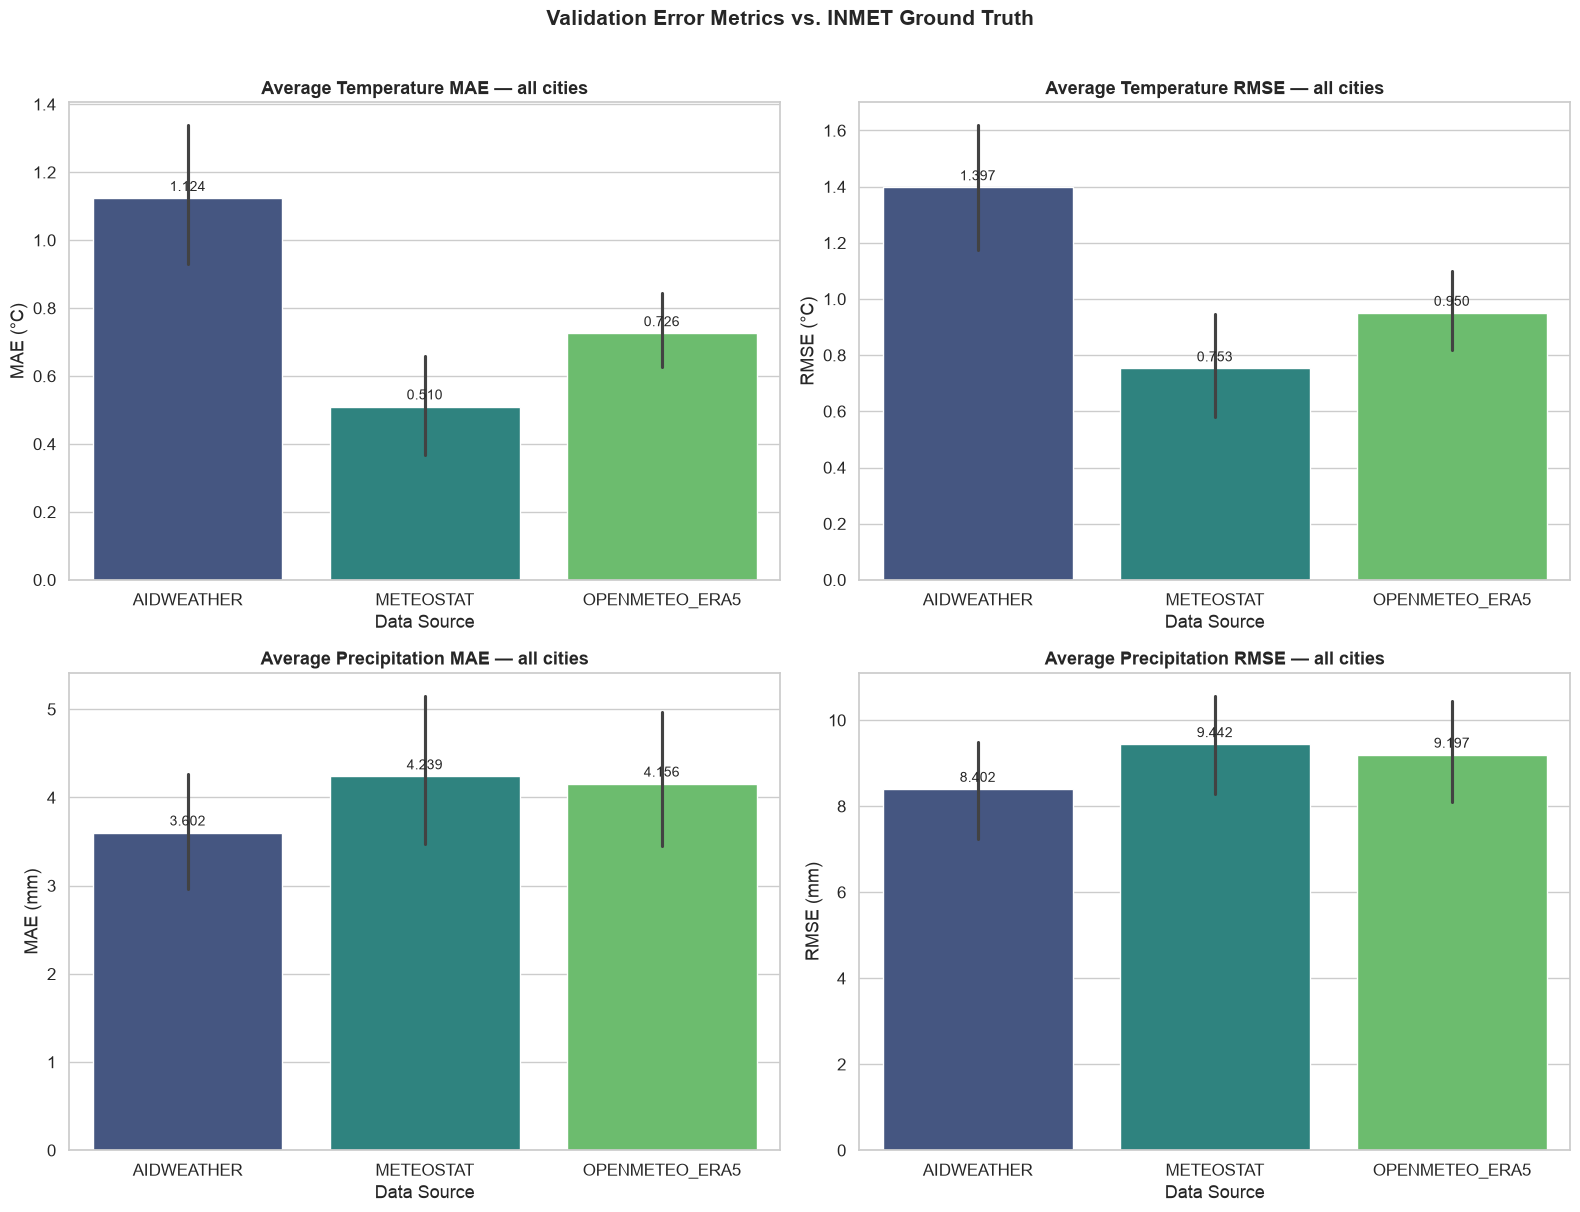

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
_source_palette = "viridis"

for i, var in enumerate(["Temperature", "Precipitation"]):
    var_df = df_metrics[df_metrics["variable"] == var]
    for j, metric in enumerate(["mae", "rmse"]):
        ax = axes[i, j]
        if var_df.empty:
            ax.set_visible(False)
            continue
        sns.barplot(
            data=var_df,
            x="source",
            y=metric,
            hue="source",
            errorbar=("ci", 95),
            ax=ax,
            palette=_source_palette,
            legend=False,
        )
        ax.set_title(
            f"Average {var} {metric.upper()} — all cities",
            fontsize=13,
            fontweight="bold",
        )
        ax.set_ylabel(f"{metric.upper()} ({'°C' if var == 'Temperature' else 'mm'})")
        ax.set_xlabel("Data Source")
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

plt.suptitle(
    "Validation Error Metrics vs. INMET Ground Truth",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
save_or_show("multi_city_error_summary.png")

 ## 6. Per-city metric heatmaps

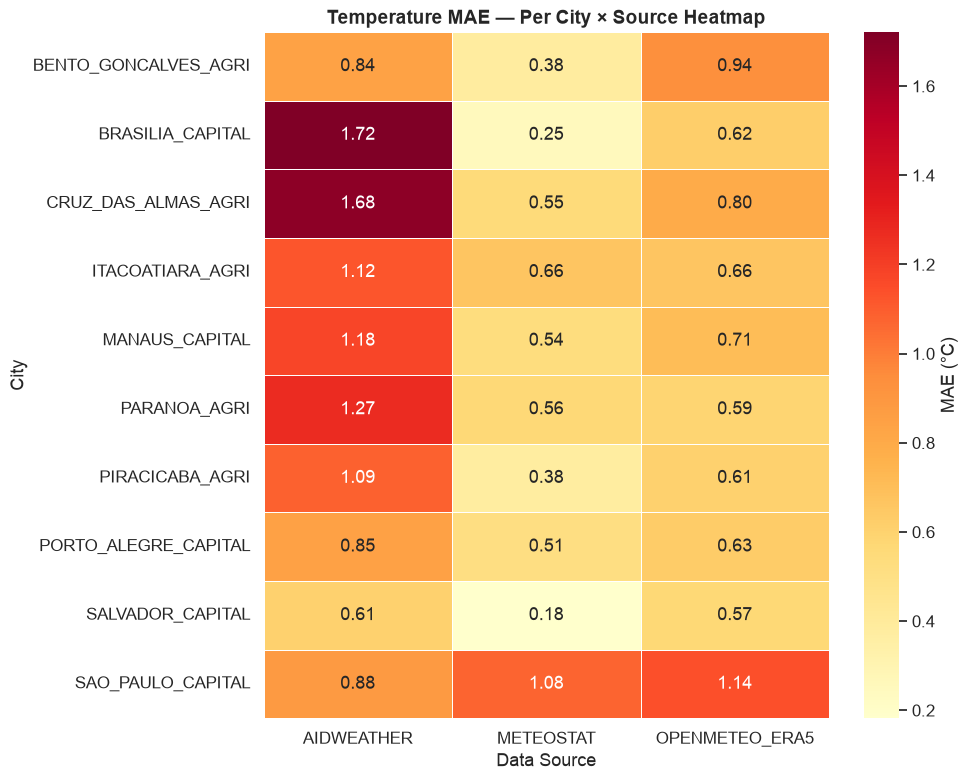

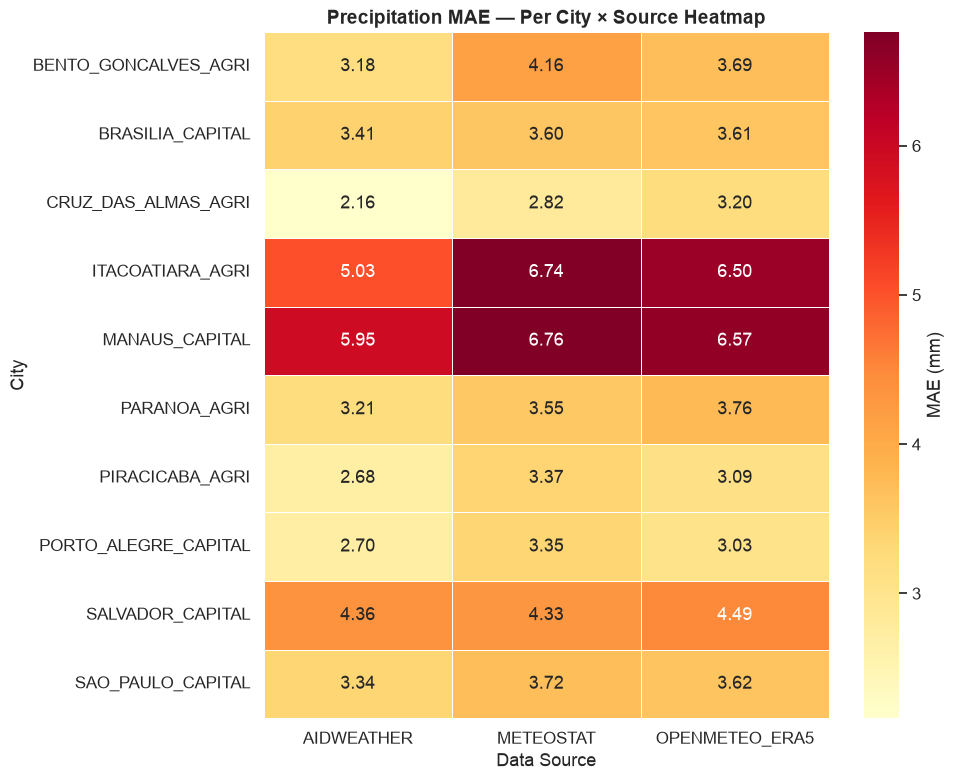

In [ ]:
for var in ["Temperature", "Precipitation"]:
    var_df = df_metrics[df_metrics["variable"] == var]
    if var_df.empty:
        continue
    pivot_mae = var_df.pivot_table(index="city", columns="source", values="mae")
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        pivot_mae,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": f"MAE ({'°C' if var == 'Temperature' else 'mm'})"},
    )
    ax.set_title(
        f"{var} MAE — Per City × Source Heatmap",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Data Source")
    ax.set_ylabel("City")
    plt.tight_layout()
    save_or_show(f"heatmap_mae_{var.lower()}.png")

 ## 7. Unsupervised ML — Dimensionality Reduction & Clustering

 Climate profiles (17 features) are standardized, then reduced with PCA and
 t-SNE. K-Means (K = 5, one per geographic region) assigns clusters.

 **Three combinatory scatter plot variants** are produced for each projection:
 - **Variant A**: Color = K-Means cluster | Shape = Tool
 - **Variant B**: Color = Tool | Shape = City type (Capital / Agri)
 - **Variant C**: Color = City | Shape = Tool

PCA explained variance: PC1 = 43.26%, PC2 = 37.88%


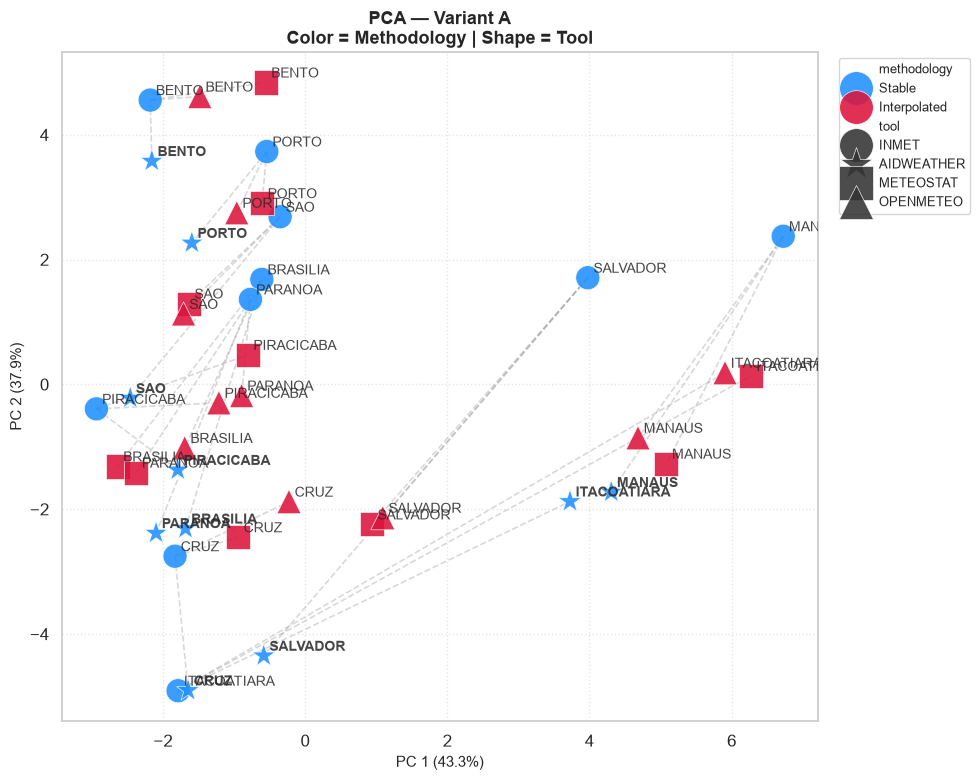

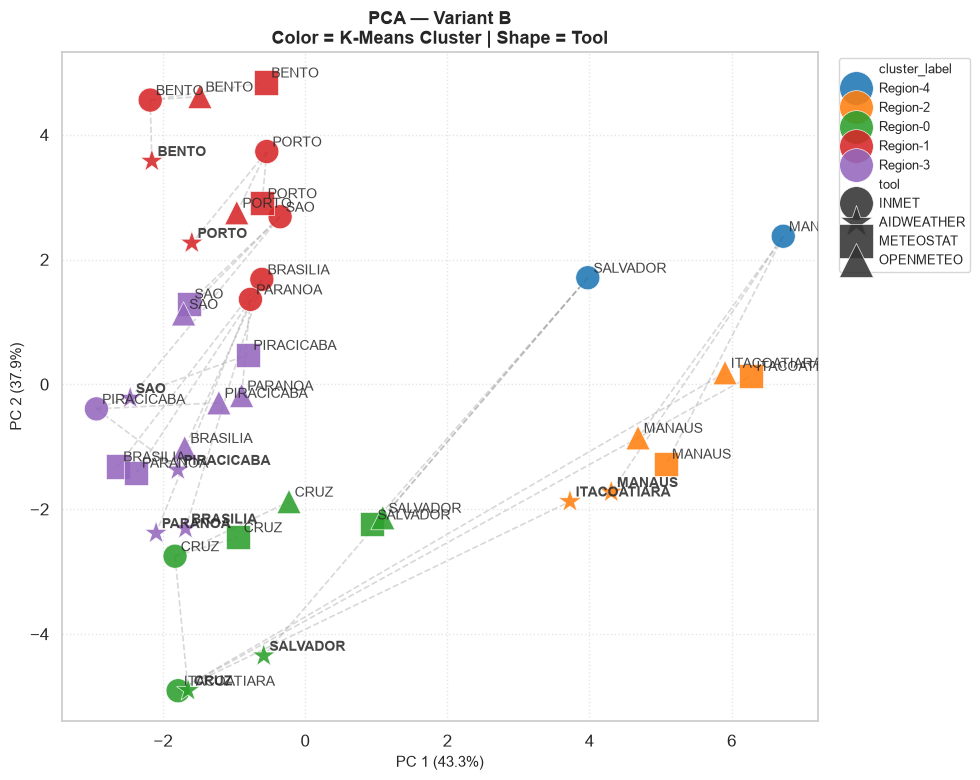

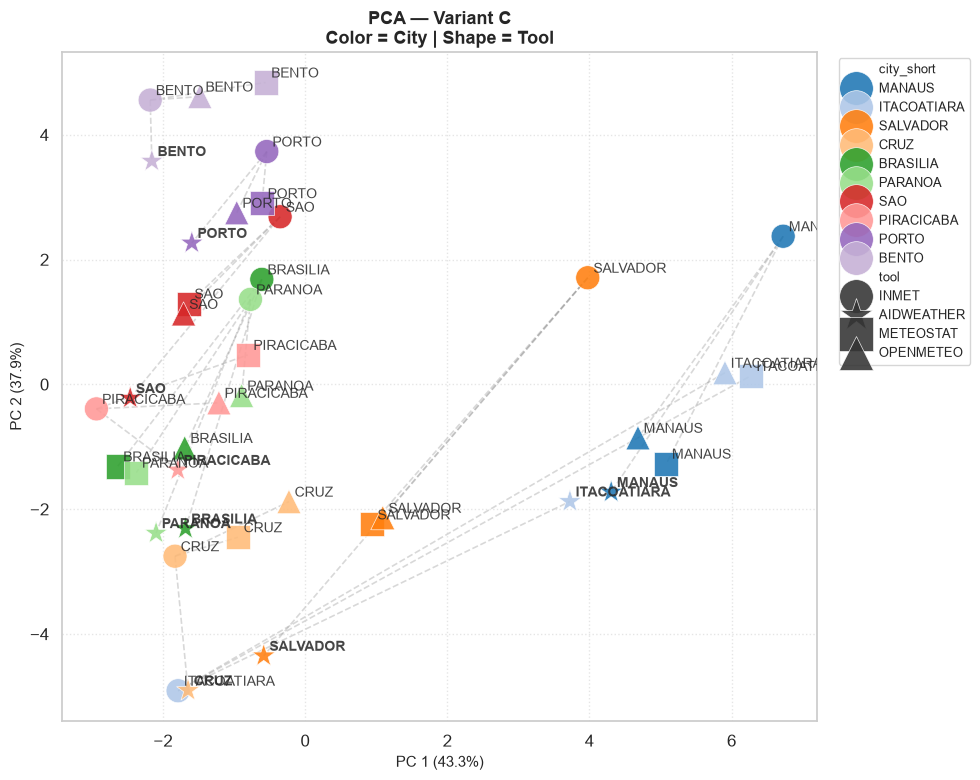

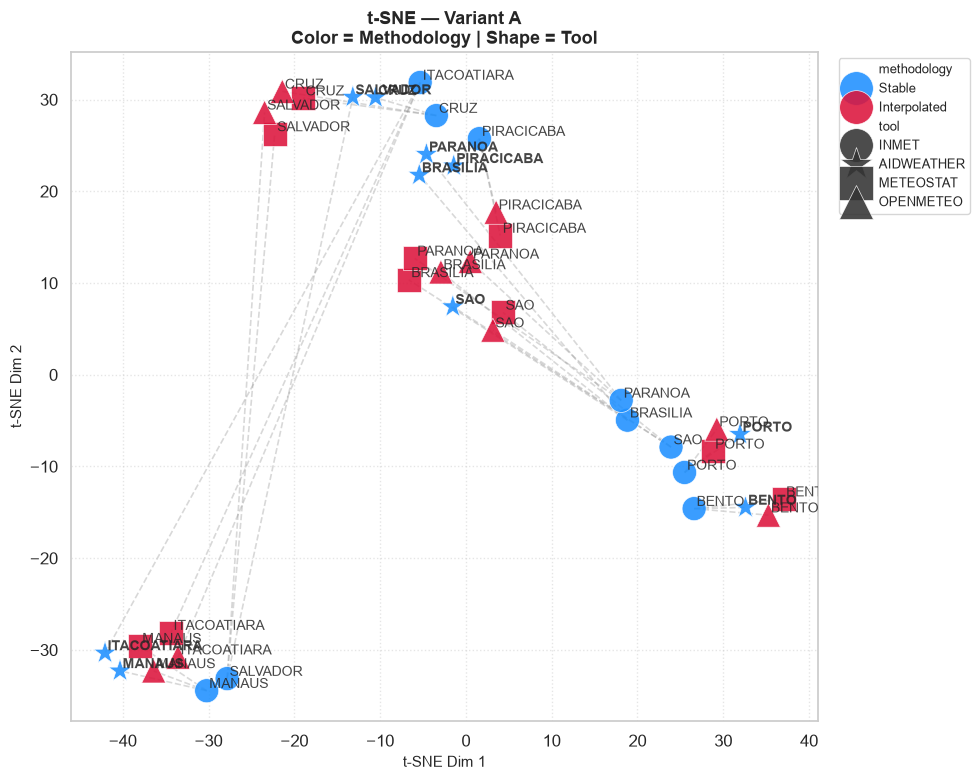

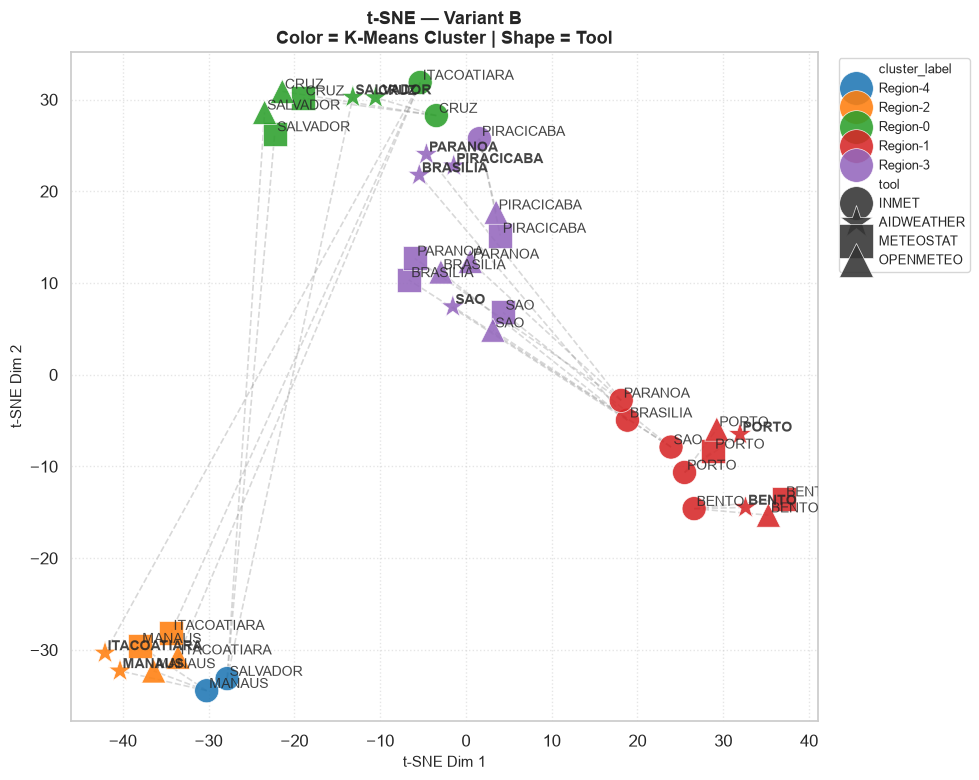

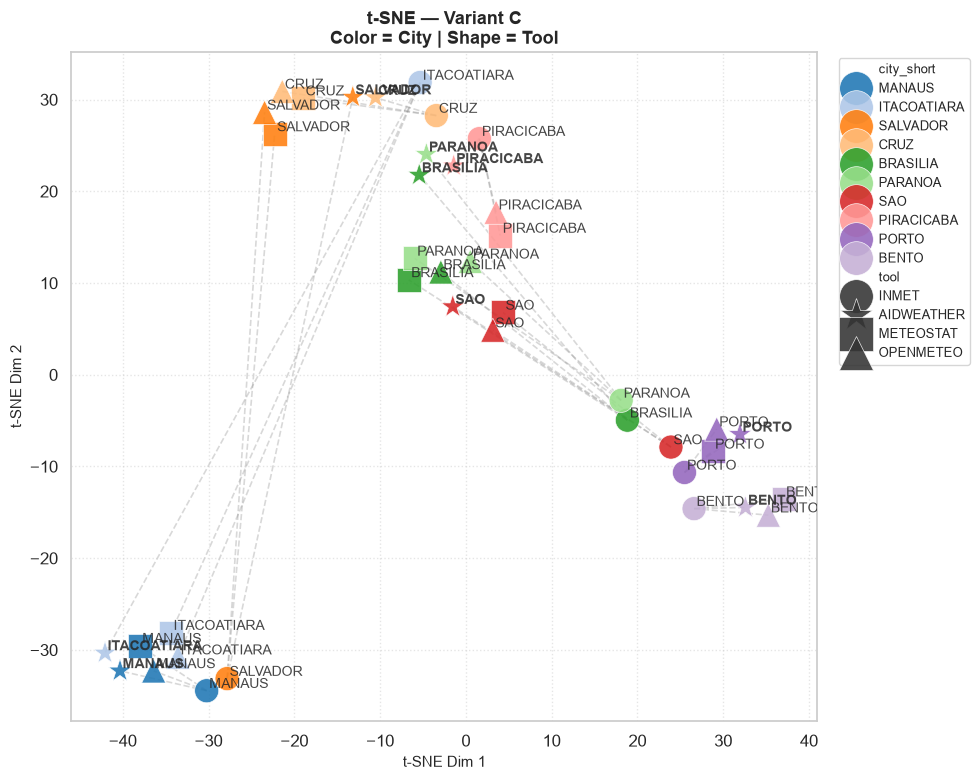

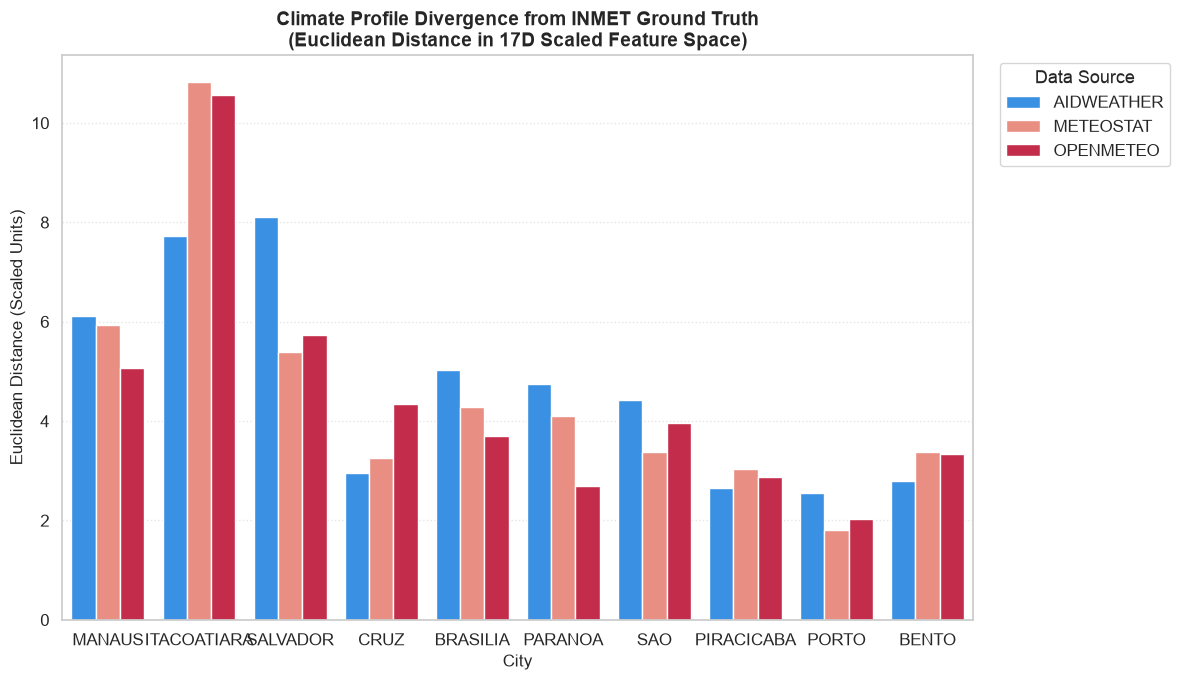


Unsupervised ML clustering and plotting complete.


In [ ]:
if len(ml_features) < 10:
    print("Skipping ML clustering: fewer than 10 complete profiles available.")
else:
    X = np.vstack(ml_features)
    labels_df = pd.DataFrame(ml_labels)

    # Standardize
    X_scaled = StandardScaler().fit_transform(X)

    # K-Means
    km = KMeans(n_clusters=5, random_state=42, n_init=10)
    labels_df["cluster"] = km.fit_predict(X_scaled)
    labels_df["cluster_label"] = labels_df["cluster"].apply(lambda x: f"Region-{x}")

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    labels_df["pca_1"] = X_pca[:, 0]
    labels_df["pca_2"] = X_pca[:, 1]
    evr = pca.explained_variance_ratio_
    print(f"PCA explained variance: PC1 = {evr[0]:.2%}, PC2 = {evr[1]:.2%}")

    # t-SNE
    perplexity = min(5, len(X_scaled) - 1)
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    labels_df["tsne_1"] = X_tsne[:, 0]
    labels_df["tsne_2"] = X_tsne[:, 1]

    # Shared plot settings
    _TOOL_MARKERS = {
        "INMET": "o",
        "AIDWEATHER": "*",
        "METEOSTAT": "s",
        "OPENMETEO": "^",
    }
    _REGION_MARKERS = {"CAPITAL": "D", "AGRI": "P"}
    _MARKER_SIZE = 300  # larger markers
    _LABEL_SIZE = 10  # annotation font size

    def _annotate(
        ax, data: pd.DataFrame, x_col: str, y_col: str, offset: float = 0.08
    ) -> None:
        """Add bold city-short labels to scatter plot points."""
        for _, row in data.iterrows():
            ax.text(
                row[x_col] + offset,
                row[y_col] + offset,
                row["city_short"],
                fontsize=_LABEL_SIZE,
                fontweight="bold" if row["tool"] == "AIDWEATHER" else "normal",
                alpha=0.85,
                clip_on=True,
            )

    def _scatter_variant(
        ax,
        data: pd.DataFrame,
        x_col: str,
        y_col: str,
        hue_col: str,
        style_col: str,
        marker_map: dict,
        palette: str | list | dict,
        title: str,
        xlabel: str,
        ylabel: str,
        offset: float = 0.08,
    ) -> None:
        """Produce a single scatter variant on ax with spider lines."""
        # Draw spider lines connecting tools to INMET for each city
        for city in data["city"].unique():
            city_data = data[data["city"] == city]
            inmet_row = city_data[city_data["tool"] == "INMET"]
            if not inmet_row.empty:
                x_center = inmet_row.iloc[0][x_col]
                y_center = inmet_row.iloc[0][y_col]
                for _, row in city_data.iterrows():
                    if row["tool"] != "INMET":
                        ax.plot(
                            [x_center, row[x_col]],
                            [y_center, row[y_col]],
                            color="gray",
                            alpha=0.3,
                            linestyle="--",
                            linewidth=1.2,
                            zorder=0,
                        )

        sns.scatterplot(
            data=data,
            x=x_col,
            y=y_col,
            hue=hue_col,
            style=style_col,
            markers=marker_map,
            palette=palette,
            s=_MARKER_SIZE,
            alpha=0.88,
            edgecolors="white",
            linewidth=0.5,
            ax=ax,
            zorder=2,
        )
        _annotate(ax, data, x_col, y_col, offset)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=9,
            markerscale=1.4,
        )

    # -----------------------------------------------------------------------
    # PCA — independent variants
    # -----------------------------------------------------------------------
    # Variant A: Methodology
    fig, ax = plt.subplots(figsize=(10, 8))
    _scatter_variant(
        ax,
        labels_df,
        "pca_1",
        "pca_2",
        hue_col="methodology",
        style_col="tool",
        marker_map=_TOOL_MARKERS,
        palette={"Stable": "dodgerblue", "Interpolated": "crimson"},
        title="PCA — Variant A\nColor = Methodology | Shape = Tool",
        xlabel=f"PC 1 ({evr[0]:.1%})",
        ylabel=f"PC 2 ({evr[1]:.1%})",
    )
    plt.tight_layout()
    save_or_show("climate_profiles_pca_methodology.png")

    # Variant B: Cluster
    fig, ax = plt.subplots(figsize=(10, 8))
    _scatter_variant(
        ax,
        labels_df,
        "pca_1",
        "pca_2",
        hue_col="cluster_label",
        style_col="tool",
        marker_map=_TOOL_MARKERS,
        palette="tab10",
        title="PCA — Variant B\nColor = K-Means Cluster | Shape = Tool",
        xlabel=f"PC 1 ({evr[0]:.1%})",
        ylabel=f"PC 2 ({evr[1]:.1%})",
    )
    plt.tight_layout()
    save_or_show("climate_profiles_pca_cluster.png")

    # Variant C: City
    fig, ax = plt.subplots(figsize=(10, 8))
    _scatter_variant(
        ax,
        labels_df,
        "pca_1",
        "pca_2",
        hue_col="city_short",
        style_col="tool",
        marker_map=_TOOL_MARKERS,
        palette="tab20",
        title="PCA — Variant C\nColor = City | Shape = Tool",
        xlabel=f"PC 1 ({evr[0]:.1%})",
        ylabel=f"PC 2 ({evr[1]:.1%})",
    )
    plt.tight_layout()
    save_or_show("climate_profiles_pca_city.png")

    # -----------------------------------------------------------------------
    # t-SNE — independent variants
    # -----------------------------------------------------------------------
    # Variant A: Methodology
    fig, ax = plt.subplots(figsize=(10, 8))
    _scatter_variant(
        ax,
        labels_df,
        "tsne_1",
        "tsne_2",
        hue_col="methodology",
        style_col="tool",
        marker_map=_TOOL_MARKERS,
        palette={"Stable": "dodgerblue", "Interpolated": "crimson"},
        title="t-SNE — Variant A\nColor = Methodology | Shape = Tool",
        xlabel="t-SNE Dim 1",
        ylabel="t-SNE Dim 2",
        offset=0.3,
    )
    plt.tight_layout()
    save_or_show("climate_profiles_tsne_methodology.png")

    # Variant B: Cluster
    fig, ax = plt.subplots(figsize=(10, 8))
    _scatter_variant(
        ax,
        labels_df,
        "tsne_1",
        "tsne_2",
        hue_col="cluster_label",
        style_col="tool",
        marker_map=_TOOL_MARKERS,
        palette="tab10",
        title="t-SNE — Variant B\nColor = K-Means Cluster | Shape = Tool",
        xlabel="t-SNE Dim 1",
        ylabel="t-SNE Dim 2",
        offset=0.3,
    )
    plt.tight_layout()
    save_or_show("climate_profiles_tsne_cluster.png")

    # Variant C: City
    fig, ax = plt.subplots(figsize=(10, 8))
    _scatter_variant(
        ax,
        labels_df,
        "tsne_1",
        "tsne_2",
        hue_col="city_short",
        style_col="tool",
        marker_map=_TOOL_MARKERS,
        palette="tab20",
        title="t-SNE — Variant C\nColor = City | Shape = Tool",
        xlabel="t-SNE Dim 1",
        ylabel="t-SNE Dim 2",
        offset=0.3,
    )
    plt.tight_layout()
    save_or_show("climate_profiles_tsne_city.png")

    # -----------------------------------------------------------------------
    # New Divergence Visualization: Euclidean Distance to INMET
    # -----------------------------------------------------------------------
    distances_list = []
    for city in labels_df["city"].unique():
        city_rows = labels_df[labels_df["city"] == city]
        inmet_idx = city_rows[city_rows["tool"] == "INMET"].index
        if len(inmet_idx) == 0:
            continue
        inmet_idx = inmet_idx[0]
        inmet_feat = X_scaled[inmet_idx]

        for idx, row in city_rows.iterrows():
            if row["tool"] == "INMET":
                continue
            dist = np.linalg.norm(X_scaled[idx] - inmet_feat)
            distances_list.append(
                {
                    "city": city,
                    "city_short": row["city_short"],
                    "tool": row["tool"],
                    "methodology": row["methodology"],
                    "euclidean_distance": dist,
                }
            )

    df_dist = pd.DataFrame(distances_list)
    if not df_dist.empty:
        fig, ax = plt.subplots(figsize=(12, 7))
        sns.barplot(
            data=df_dist,
            x="city_short",
            y="euclidean_distance",
            hue="tool",
            palette={
                "AIDWEATHER": "dodgerblue",
                "METEOSTAT": "salmon",
                "OPENMETEO": "crimson",
            },
            ax=ax,
        )
        ax.set_title(
            "Climate Profile Divergence from INMET Ground Truth\n(Euclidean Distance in 17D Scaled Feature Space)",
            fontsize=14,
            fontweight="bold",
        )
        ax.set_xlabel("City", fontsize=12)
        ax.set_ylabel("Euclidean Distance (Scaled Units)", fontsize=12)
        ax.grid(True, linestyle=":", alpha=0.5, axis="y")
        ax.legend(title="Data Source", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        save_or_show("climate_divergence_from_inmet.png")

    print("\nUnsupervised ML clustering and plotting complete.")

 ## 8. Timeseries Comparison Grid (5 Capital Locations, 7-day Moving Average)

 This section plots a grid of timeseries comparisons for the 5 capital locations representing
 the 5 Brazilian regions. It applies a 7-day moving average to smooth the data over the full
 time period, making daily weather trends across sources (INMET, AidWeather, Meteostat,
 Open-Meteo ERA5) easier to compare.

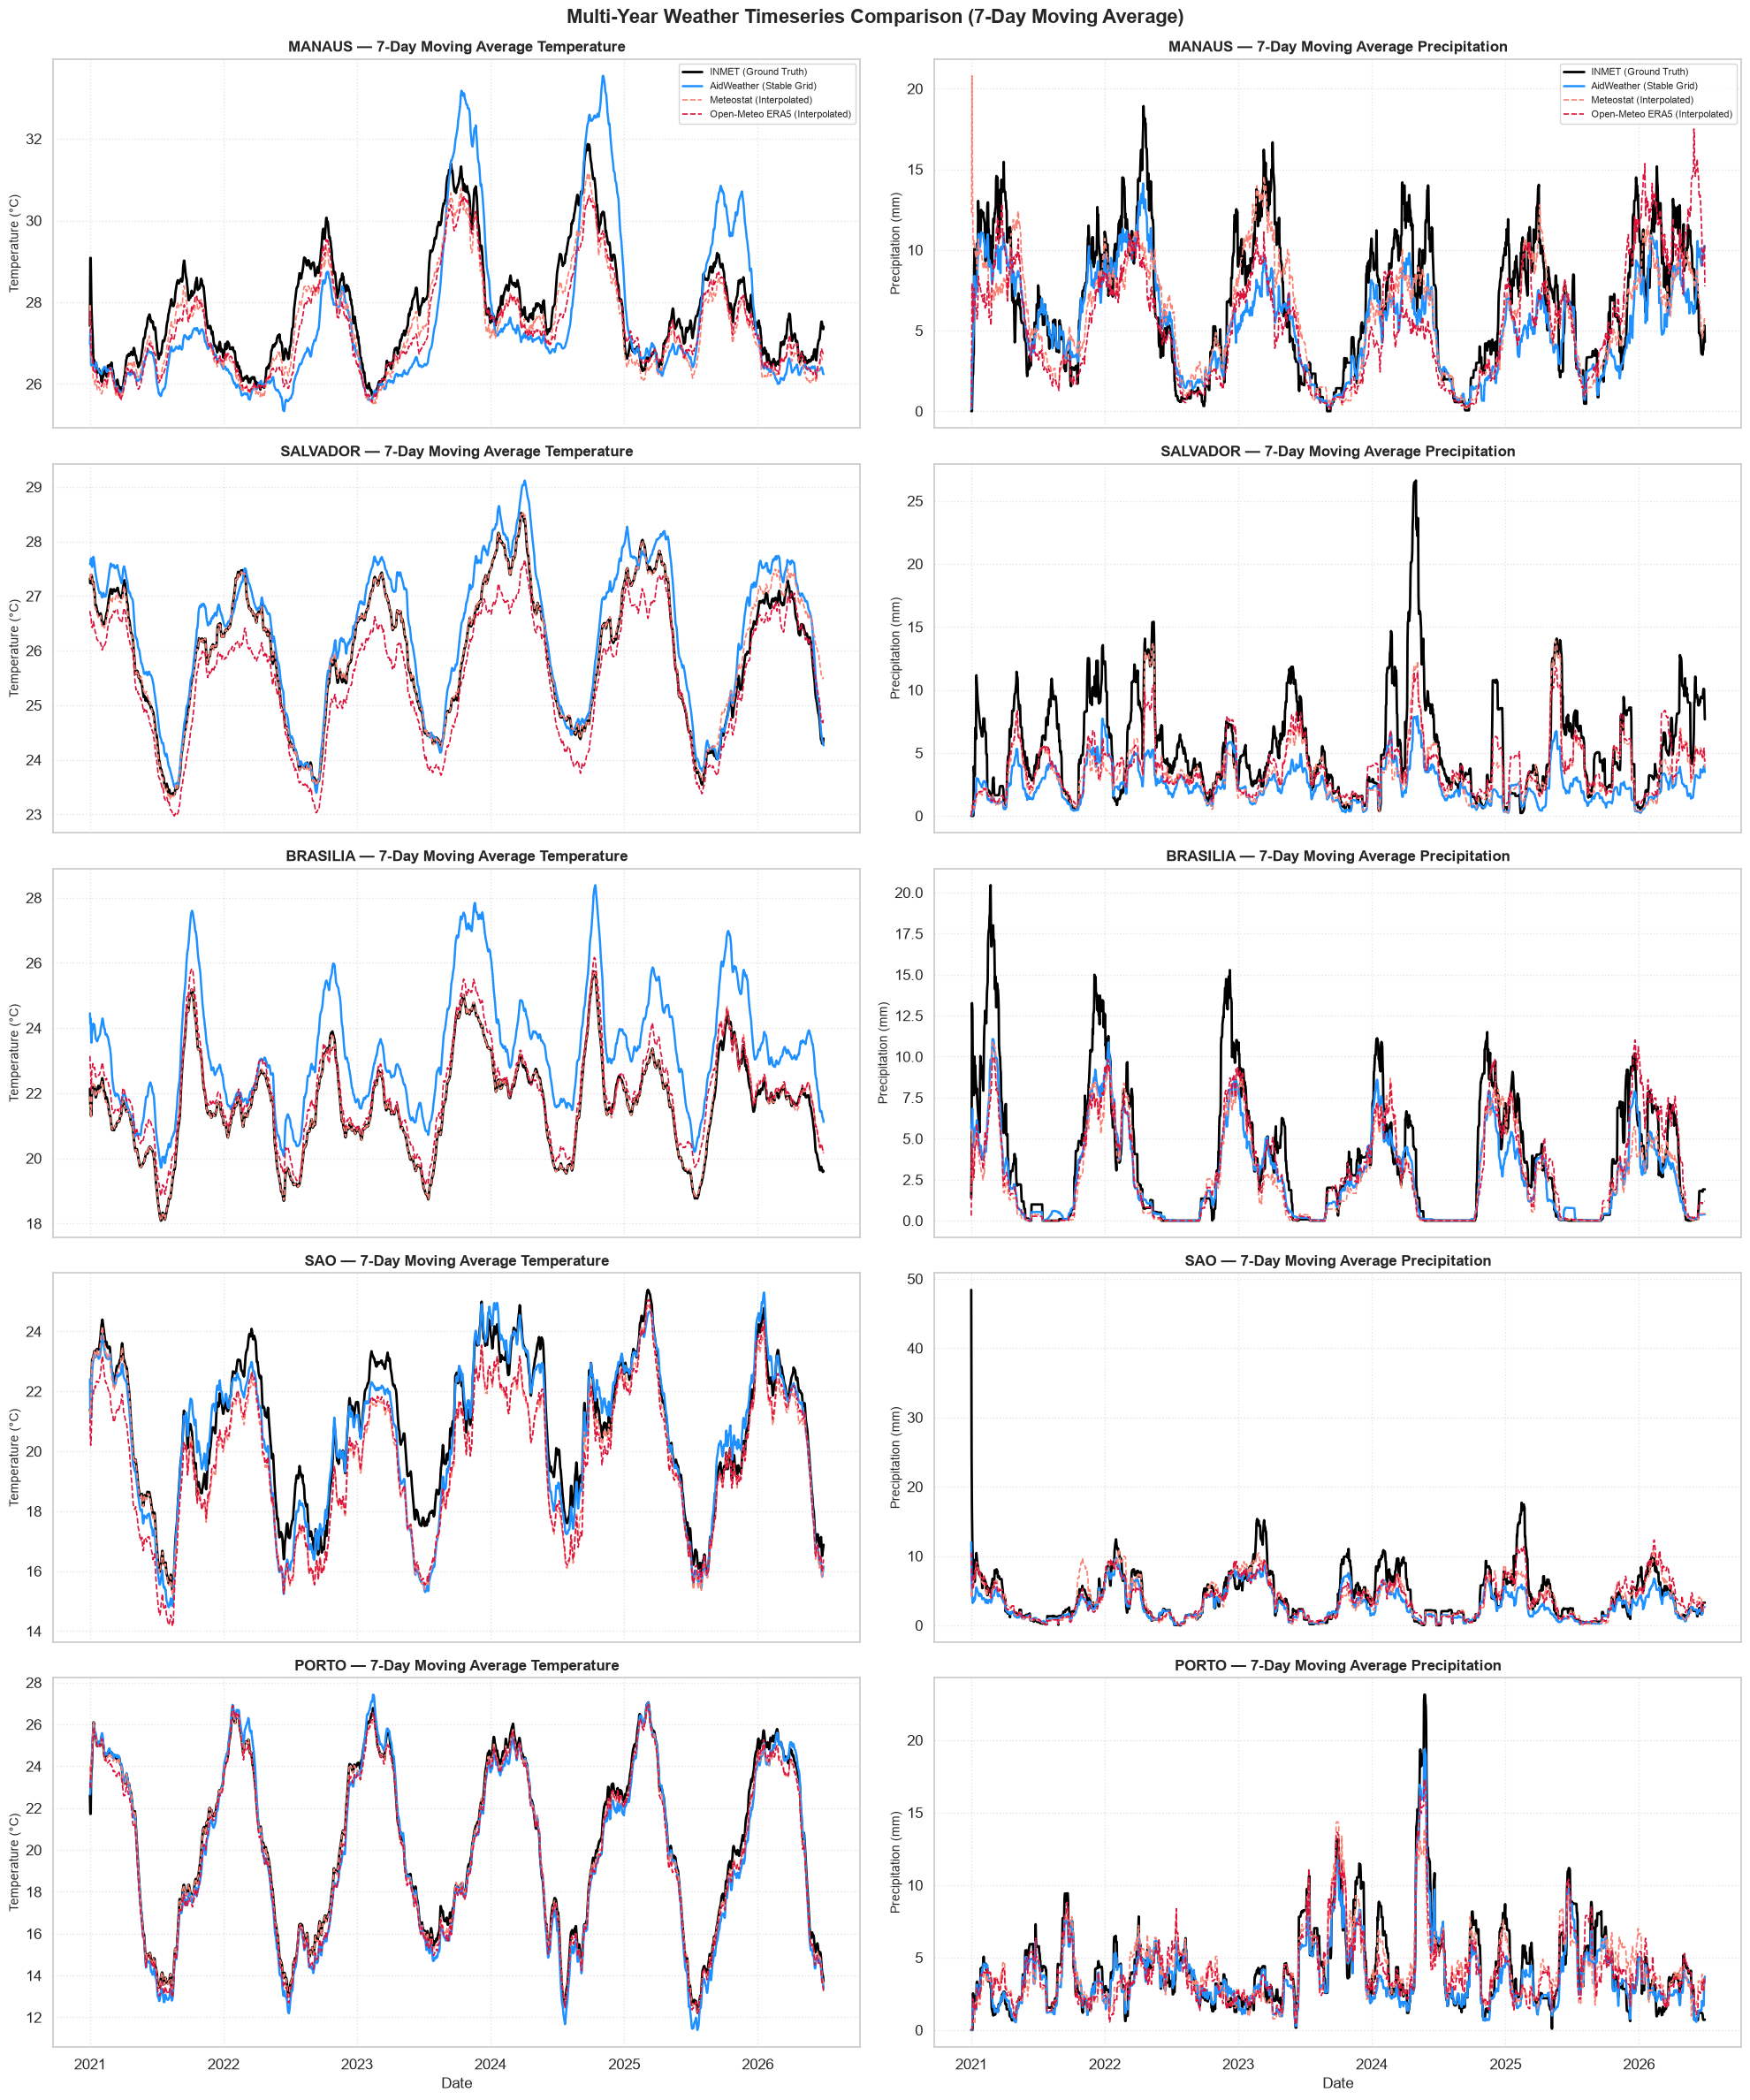

In [ ]:
grid_cities = [
    "MANAUS_CAPITAL",
    "SALVADOR_CAPITAL",
    "BRASILIA_CAPITAL",
    "SAO_PAULO_CAPITAL",
    "PORTO_ALEGRE_CAPITAL",
]

# Create a 5x2 grid: Rows = Cities, Columns = Temperature, Precipitation
fig, axes = plt.subplots(5, 2, figsize=(20, 24), sharex=True)

t_cols = {
    "T2M_INMET": ("INMET (Ground Truth)", "black", "-", 2.0),
    "T2M_AIDWEATHER": ("AidWeather (Stable Grid)", "dodgerblue", "-", 1.8),
    "T2M_METEOSTAT": ("Meteostat (Interpolated)", "salmon", "--", 1.2),
    "T2M_OPENMETEO_ERA5": ("Open-Meteo ERA5 (Interpolated)", "crimson", "--", 1.2),
}

p_cols = {
    "PRECTOT_INMET": ("INMET (Ground Truth)", "black", "-", 2.0),
    "PRECTOT_AIDWEATHER": ("AidWeather (Stable Grid)", "dodgerblue", "-", 1.8),
    "PRECTOT_METEOSTAT": ("Meteostat (Interpolated)", "salmon", "--", 1.2),
    "PRECTOT_OPENMETEO_ERA5": ("Open-Meteo ERA5 (Interpolated)", "crimson", "--", 1.2),
}

for i, city in enumerate(grid_cities):
    if city in combined_data:
        df_city = combined_data[city]
        # Apply 7-day rolling average
        df_rolling = df_city.rolling(window=30, min_periods=1).mean()

        # Temperature subplot
        ax_temp = axes[i, 0]
        for col, (label, color, style, width) in t_cols.items():
            if col in df_rolling.columns:
                ax_temp.plot(
                    df_rolling.index,
                    df_rolling[col],
                    label=label,
                    color=color,
                    linestyle=style,
                    linewidth=width,
                )
        city_name = city.split("_")[0]
        ax_temp.set_title(
            f"{city_name} — 7-Day Moving Average Temperature",
            fontsize=12,
            fontweight="bold",
        )
        ax_temp.set_ylabel("Temperature (°C)", fontsize=10)
        ax_temp.grid(True, linestyle=":", alpha=0.5)
        if i == 0:
            ax_temp.legend(loc="upper right", fontsize=8)

        # Precipitation subplot
        ax_precip = axes[i, 1]
        for col, (label, color, style, width) in p_cols.items():
            if col in df_rolling.columns:
                ax_precip.plot(
                    df_rolling.index,
                    df_rolling[col],
                    label=label,
                    color=color,
                    linestyle=style,
                    linewidth=width,
                )
        ax_precip.set_title(
            f"{city_name} — 7-Day Moving Average Precipitation",
            fontsize=12,
            fontweight="bold",
        )
        ax_precip.set_ylabel("Precipitation (mm)", fontsize=10)
        ax_precip.grid(True, linestyle=":", alpha=0.5)
        if i == 0:
            ax_precip.legend(loc="upper right", fontsize=8)
    else:
        axes[i, 0].set_visible(False)
        axes[i, 1].set_visible(False)

# Add shared X labels
for j in range(2):
    axes[-1, j].set_xlabel("Date", fontsize=12)

plt.suptitle(
    "Multi-Year Weather Timeseries Comparison (7-Day Moving Average)",
    fontsize=16,
    fontweight="bold",
    y=0.99,
)
plt.tight_layout()
save_or_show("daily_timeseries_comparison.png")